# Random Forest: обучение и визуализация

В этой тетрадке я показываю базовый пример работы `RandomForestClassifier` из `sklearn`: обучаю лес, считаю метрики и рисую границу решений. Код специально оставлен не слишком большим, чтобы было видно не оформление вокруг модели, а основные шаги: данные, обучение, проверка качества и несколько визуализаций.


## 1. Импорт библиотек

Здесь подключаются только нужные для демонстрации библиотеки. `numpy` нужен для сетки точек, `matplotlib` — для графиков, `sklearn` — для датасета, модели и метрик.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

## 2. Датасет

Возьмем двумерную задачу `make_moons`. Она хорошо подходит для Random Forest: классы нельзя нормально отделить одной прямой, зато дерево может разбивать плоскость кусками, а лес собирает из этих кусков более устойчивую границу.


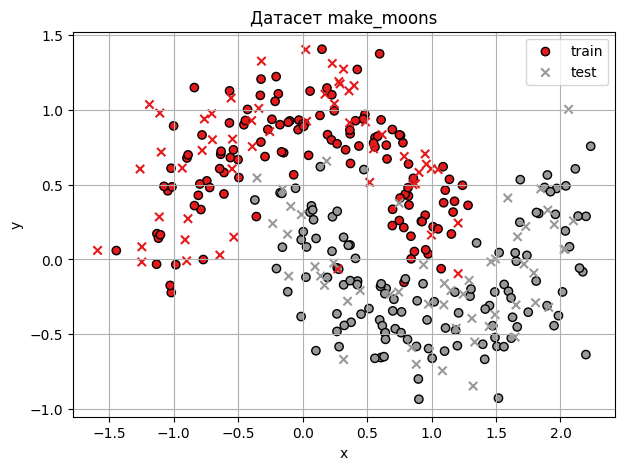

In [2]:
X, y = make_moons(n_samples=350, noise=0.22, random_state=42)

# Делим данные на обучающую и тестовую части.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="Set1", edgecolor="k", label="train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="Set1", marker="x", label="test")
plt.title("Датасет make_moons")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 3. Обучение Random Forest

Дальше задаются основные параметры леса:

- `n_estimators` — сколько деревьев будет в ансамбле;
- `max_depth` — насколько глубоко может расти каждое дерево;
- `min_samples_leaf` — минимальное число объектов в листе;
- `max_features` — сколько признаков дерево рассматривает при поиске split;
- `bootstrap=True` — каждое дерево обучается на случайной выборке с возвращением.


### Небольшая теория перед обучением

В дереве нужно выбрать такой split, после которого классы в дочерних вершинах станут более чистыми. Для этого часто используют критерий Gini impurity:

$$
G(S) = 1 - \sum_{k=1}^{K} p_k^2,
$$

где $p_k$ — доля объектов класса $k$ в множестве $S$. Для бинарной классификации это можно записать так:

$$
G(S) = 1 - p^2 - (1-p)^2.
$$

Качество разбиения удобно считать через уменьшение impurity:

$$
\Delta G = G(S) - \frac{|S_L|}{|S|}G(S_L) - \frac{|S_R|}{|S|}G(S_R).
$$

Дерево перебирает возможные пороги и выбирает split с максимальным $\Delta G$. Random Forest повторяет это для многих деревьев, обученных на bootstrap-выборках, а итоговая вероятность получается усреднением:

$$
\hat p(x) = \frac{1}{T}\sum_{t=1}^{T} h_t(x).
$$

Если $\hat p(x) \ge 0.5$, модель относит объект к классу `1`, иначе к классу `0`.


In [3]:
forest = RandomForestClassifier(
    n_estimators=80,
    max_depth=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
)

forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",80
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

## 4. Метрики качества

Для тестовой части считаются accuracy, precision, recall, F-метрика, AUC-ROC и AUC-PR. Для AUC нужны не только классы, но и вероятности класса `1`, поэтому отдельно берется `predict_proba`.


accuracy  : 0.924
precision : 0.958
recall    : 0.885
f1        : 0.920
auc_roc   : 0.978
auc_pr    : 0.980


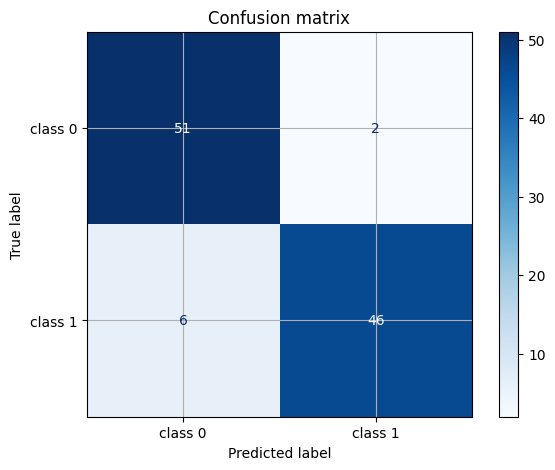

In [4]:
y_pred = forest.predict(X_test)
y_score = forest.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "auc_roc": roc_auc_score(y_test, y_score),
    "auc_pr": average_precision_score(y_test, y_score),
}

for name, value in metrics.items():
    print(f"{name:10s}: {value:.3f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["class 0", "class 1"]).plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

## 5. Граница решений

Чтобы увидеть поведение модели на плоскости, строится сетка точек. Для каждой точки из сетки лес предсказывает вероятность класса `1`, а затем эта вероятность раскрашивается как фон.


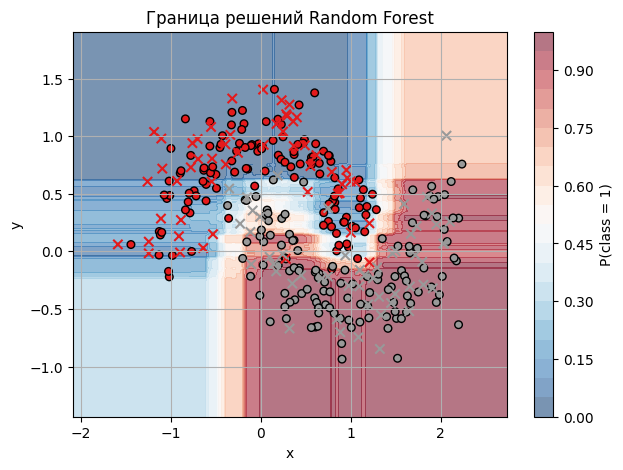

In [8]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250),
)
grid = np.c_[xx.ravel(), yy.ravel()]
proba = forest.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.contourf(xx, yy, proba, levels=20, cmap="RdBu_r", alpha=0.55)
plt.colorbar(label="P(class = 1)")
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="Set1", edgecolor="k", s=30)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="Set1", marker="x", s=45)
plt.title("Граница решений Random Forest")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 6. Важность признаков

`feature_importances_` показывает, какую долю суммарного уменьшения impurity дали разные признаки. В этом примере признаков всего два — координаты `x` и `y`, поэтому график получается совсем коротким, но принцип тот же, что и для большего числа признаков.


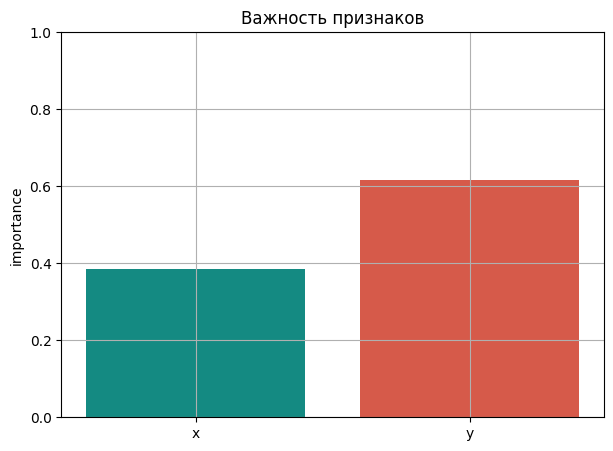

x: 0.384
y: 0.616


In [6]:
feature_names = ["x", "y"]
importances = forest.feature_importances_

plt.bar(feature_names, importances, color=["#148a82", "#d65a4a"])
plt.ylim(0, 1)
plt.title("Важность признаков")
plt.ylabel("importance")
plt.show()

for name, value in zip(feature_names, importances):
    print(f"{name}: {value:.3f}")

## 7. Одно дерево из леса

Random Forest состоит из отдельных деревьев. Ниже нарисовано первое дерево ансамбля. В web-приложении используется похожая идея: можно смотреть первые деревья и видеть, какие условия они строят.


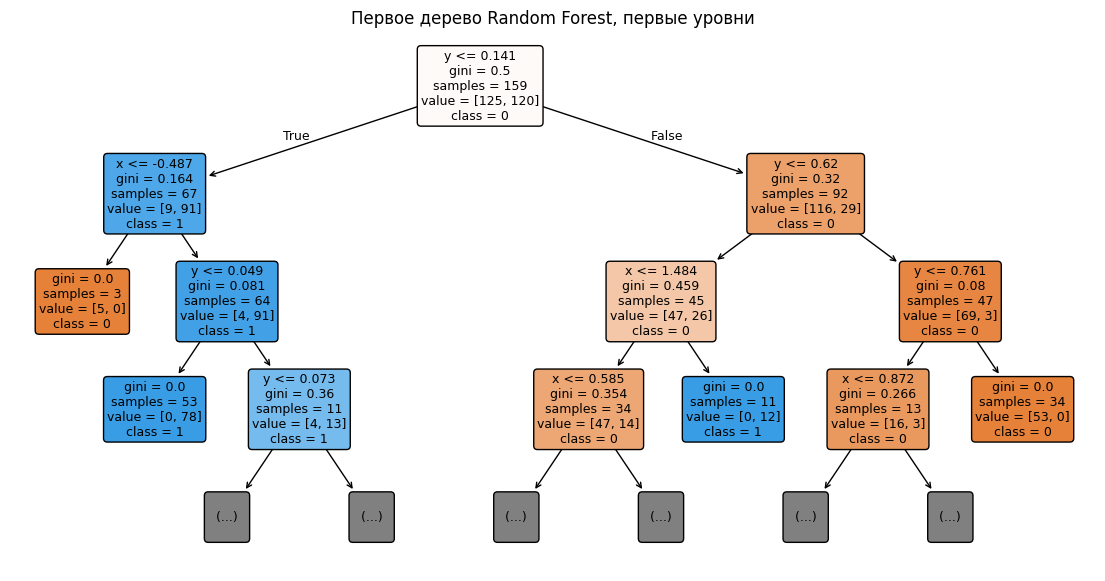

In [7]:
plt.figure(figsize=(14, 7))
plot_tree(
    forest.estimators_[0],
    feature_names=feature_names,
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)
plt.title("Первое дерево Random Forest, первые уровни")
plt.show()

## 8. Связь с web-приложением

В тетрадке используется готовая реализация из `sklearn`, а в web-приложении логика дерева и леса написана на JavaScript. Notebook нужен как более привычный ML-пример, а сайт — как интерактивная визуализация того, что происходит внутри алгоритма.
